In [1]:
# =====================================================================
# CELL 1: ENVIRONMENT & MODEL SETUP
# =====================================================================
!pip uninstall -y torchvision -q
!pip install transformers==4.46.2 accelerate safetensors sentencepiece einops datasets scikit-learn -q

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

# 1. Load Diffusion-LLM (LLaDA)
model_name = "GSAI-ML/LLaDA-8B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
if tokenizer.padding_side != 'left':
    tokenizer.padding_side = 'left'

# Use bfloat16 to fit in memory (Colab L4 or Kaggle T4x2)
model = AutoModel.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="balanced",
    trust_remote_code=True
).eval()
print("LLaDA-8B-Instruct loaded.")

# 2. Load Semantic Embedder for TVS calculation
embedder = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
print("SentenceTransformer loaded.")

# Global Configuration
NUM_DIFFUSION_STEPS = 50
TEMPERATURE = 1.0
NUM_SEEDS = 5
SEEDS = list(range(NUM_SEEDS))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 111.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.27 requires torchvision, which is not installed.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer loaded.


In [2]:
%%writefile llada_generate.py
import torch
import numpy as np
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

def add_gumbel_noise(logits, temperature):
    if temperature == 0: return logits
    logits = logits.to(torch.float64)
    noise = torch.rand_like(logits, dtype=torch.float64)
    gumbel_noise = (- torch.log(noise)) ** temperature
    return logits.exp() / gumbel_noise

def get_num_transfer_tokens(mask_index, steps):
    mask_num = mask_index.sum(dim=1, keepdim=True)
    base = mask_num // steps
    remainder = mask_num % steps
    num_transfer_tokens = torch.zeros(mask_num.size(0), steps, device=mask_index.device, dtype=torch.int64) + base
    for i in range(mask_num.size(0)):
        num_transfer_tokens[i, :remainder[i]] += 1
    return num_transfer_tokens

@torch.no_grad()
def generate(model, prompt, attention_mask=None, steps=128, gen_length=128, block_length=128, temperature=0., cfg_scale=0., remasking='low_confidence', mask_id=126336):
    x = torch.full((prompt.shape[0], prompt.shape[1] + gen_length), mask_id, dtype=torch.long).to(model.device)
    x[:, :prompt.shape[1]] = prompt.clone()

    if attention_mask is not None:
        attention_mask = torch.cat([attention_mask, torch.ones((prompt.shape[0], gen_length), dtype=attention_mask.dtype, device=model.device)], dim=-1)

    prompt_index = (x != mask_id)
    num_blocks = gen_length // block_length
    steps = steps // num_blocks
    history = []

    for num_block in range(num_blocks):
        block_mask_index = (x[:, prompt.shape[1] + num_block * block_length: prompt.shape[1] + (num_block + 1) * block_length:] == mask_id)
        num_transfer_tokens = get_num_transfer_tokens(block_mask_index, steps)
        for i in range(steps):
            mask_index = (x == mask_id)
            logits = model(x, attention_mask=attention_mask).logits
            logits_with_noise = add_gumbel_noise(logits, temperature=temperature)
            x0 = torch.argmax(logits_with_noise, dim=-1)

            p = F.softmax(logits, dim=-1)
            x0_p = torch.squeeze(torch.gather(p, dim=-1, index=torch.unsqueeze(x0, -1)), -1)
            x0_p[:, prompt.shape[1] + (num_block + 1) * block_length:] = -np.inf

            x0 = torch.where(mask_index, x0, x)
            confidence = torch.where(mask_index, x0_p, -np.inf)

            transfer_index = torch.zeros_like(x0, dtype=torch.bool, device=x0.device)
            for j in range(confidence.shape[0]):
                _, select_index = torch.topk(confidence[j], k=num_transfer_tokens[j, i])
                transfer_index[j, select_index] = True
            x[transfer_index] = x0[transfer_index]
            history.append(x0.clone())
    return x, history

Writing llada_generate.py


In [3]:
# =====================================================================
# CELL 3: TRAJECTORY VARIANCE SCORE (TVS) MATH & UTILS
# =====================================================================
import sys
import importlib
import re
from sklearn.metrics.pairwise import cosine_similarity

# Reload the custom generator we just wrote
import llada_generate
importlib.reload(llada_generate)
from llada_generate import generate as llada_diffusion_generate

def build_prompt(question, context=None):
    user_content = f"Context:\n{context}\n\nQuestion:\n{question}" if context else question
    messages = [
        {"role": "system", "content": "You are a helpful and knowledgeable AI assistant."},
        {"role": "user", "content": user_content}
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def semantic_variance_isolated(outputs, base_sentence):
    """Calculates pairwise cosine distance of isolated predicted entities across seeds."""
    isolated_entities = []
    for text in outputs:
        raw_answer = text.split(base_sentence)[-1] if base_sentence in text else text
        clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
        isolated_entities.append(clean_answer if clean_answer else "[EMPTY_TOKEN]")

    embeddings = embedder.encode(isolated_entities)
    dist = 1 - cosine_similarity(embeddings)
    i, j = np.triu_indices(len(outputs), k=1)
    return np.clip(dist[i, j].mean(), 0, None)

print("TVS Framework functions loaded successfully.")

TVS Framework functions loaded successfully.


In [4]:
def generate_trajectory_batched(prompt, num_seeds=5):
    """Generates all 5 seed timelines simultaneously on the GPU."""
    # Lock seed for reproducibility of the batch itself
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # Stack the prompt 5 times to form a batch
    inputs = tokenizer([prompt] * num_seeds, return_tensors="pt", padding=True).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        final_out, history = llada_diffusion_generate(
            model,
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            steps=NUM_DIFFUSION_STEPS,
            gen_length=32,
            block_length=32,
            temperature=TEMPERATURE, # High temperature ensures the 5 batch items diverge
            remasking='low_confidence'
        )

    # Initialize a list of lists: all_trajectories[seed_index][step_index]
    all_trajectories = [[] for _ in range(num_seeds)]

    # Unpack the batch across all 50 timesteps
    for step_tensor in history:
        # Decode the generated portion for the entire batch at this timestep
        step_tokens = step_tensor[:, prompt_len:]
        texts = tokenizer.batch_decode(step_tokens, skip_special_tokens=True)

        # Append the text to the correct seed's timeline
        for seed_idx, text in enumerate(texts):
            all_trajectories[seed_idx].append(text.strip())

    return all_trajectories

def run_scenario(prompt, base_sentence, num_seeds=5):
    """The updated scenario runner that uses the batched generator."""
    # Get all 5 histories in one massive forward pass
    all_trajectories = generate_trajectory_batched(prompt, num_seeds)

    variances = []
    # Calculate variance across seeds at each specific timestep
    for step in range(NUM_DIFFUSION_STEPS):
        step_outputs = [traj[step] for traj in all_trajectories]

        # Pass both the outputs AND the base sentence so it knows what to strip
        variances.append(semantic_variance_isolated(step_outputs, base_sentence))

    return variances

In [5]:
import re
import torch

# ---> 1. RE-DEFINE THE HELPER FUNCTION <---
def extract_final_entity(text, base_sentence):
    """Helper to strip grammar and isolate the predicted entity."""
    if base_sentence.lower() in text.lower():
        raw_answer = text.lower().split(base_sentence.lower())[-1]
    else:
        raw_answer = text

    # Strip punctuation, convert to lowercase, and strip whitespace
    clean_answer = re.sub(r'[^a-zA-Z0-9\s]', '', raw_answer).strip().lower()
    return clean_answer


# ---> 2. DEFINE THE UPDATED 2D BATCHING GENERATOR <---
def check_memorization_batched_2d(prompts, base_sentences, true_answers, num_seeds=5):
    """
    Evaluates multiple facts, with multiple seeds per fact, simultaneously.
    Ensures symmetrical text cleaning for accurate subset matching.
    """
    expanded_prompts = [p for p in prompts for _ in range(num_seeds)]

    inputs = tokenizer(expanded_prompts, return_tensors="pt", padding=True).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        final_out, _ = llada_diffusion_generate(
            model,
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            steps=NUM_DIFFUSION_STEPS,
            gen_length=32,
            block_length=32,
            temperature=TEMPERATURE,
            remasking='low_confidence'
        )

    outputs = tokenizer.batch_decode(final_out[:, prompt_len:], skip_special_tokens=True)

    results = []
    for i in range(len(prompts)):
        fact_outputs = outputs[i * num_seeds : (i + 1) * num_seeds]

        # --- THE FIX: Clean the true answer the exact same way ---
        clean_true = re.sub(r'[^a-zA-Z0-9\s]', '', true_answers[i]).strip().lower()

        correct_count = 0
        for text in fact_outputs:
            clean_predicted = extract_final_entity(text, base_sentences[i])

            # Now we are comparing clean string to clean string
            if clean_true in clean_predicted:
                correct_count += 1

        results.append(correct_count)

    return results

print("Updated Generator functions loaded and ready!")

Updated Generator functions loaded and ready!


In [ ]:
# =====================================================================
# CELL 4: INGEST & UNIFY ALL DATASETS
# =====================================================================
from datasets import load_dataset
import random
from collections import defaultdict

random.seed(42)
raw_eval_pool = []
size = 3000

print("1. Loading SciQ...")
sciq_data = list(load_dataset("sciq", split="train"))
random.shuffle(sciq_data)
print(len(sciq_data))
for row in sciq_data[:size]:
    raw_eval_pool.append({
        "subject": row["support"].split()[0] if row["support"] else "Science Fact",
        "base": row["question"],
        "true": row["correct_answer"],
        "fake": row["distractor1"], # Built-in plausible fake
        "dataset": "sciq"
    })

print("2. Loading CounterFact...")
cf_data = list(load_dataset("NeelNanda/counterfact-tracing", split="train"))
random.shuffle(cf_data)
print(len(cf_data))
for row in cf_data[:size]:
    raw_eval_pool.append({
        "subject": row['subject'],
        "base": row['prompt'],
        "true": row['target_true'],
        "fake": row['target_false'], # Built-in fake
        "dataset": "counterfact"
    })

print("3. Loading PopQA...")
popqa_data = list(load_dataset("akariasai/PopQA", split="test"))
print(len(popqa_data))
# Group true answers by property to generate highly plausible RAG fakes
relation_groups = defaultdict(list)
for row in popqa_data:
    relation_groups[row['prop']].append(str(row['obj']))
valid_relations = {k: list(set(v)) for k, v in relation_groups.items() if len(set(v)) > 5}

random.shuffle(popqa_data)
popqa_count = 0
for row in popqa_data:
    rel = row['prop']
    if rel not in valid_relations: continue
    true_ans = str(row['obj']).strip()
    possible_fakes = [ans for ans in valid_relations[rel] if ans != true_ans]
    if not possible_fakes: continue

    raw_eval_pool.append({
        "subject": str(row['subj']),
        "base": str(row['question']).strip(),
        "true": true_ans,
        "fake": random.choice(possible_fakes),
        "dataset": "popqa"
    })
    popqa_count += 1
    if popqa_count >= size: break

print("4. Generating Synthetic Relational Data...")
# ---> INSERT FULL DICTIONARY HERE <---
raw_knowledge = {
    "Capital": {
        "template": "The capital of {subject} is",
        "facts": {
            "Afghanistan": "Kabul", "Albania": "Tirana", "Algeria": "Algiers", "Andorra": "Andorra la Vella", "Angola": "Luanda", "Argentina": "Buenos Aires", "Armenia": "Yerevan", "Australia": "Canberra", "Austria": "Vienna", "Azerbaijan": "Baku", "Bahamas": "Nassau", "Bahrain": "Manama", "Bangladesh": "Dhaka", "Barbados": "Bridgetown", "Belarus": "Minsk", "Belgium": "Brussels", "Belize": "Belmopan", "Bhutan": "Thimphu", "Bolivia": "Sucre", "Bosnia": "Sarajevo", "Botswana": "Gaborone", "Brazil": "Brasilia", "Brunei": "Bandar Seri Begawan", "Bulgaria": "Sofia", "Burundi": "Gitega", "Cambodia": "Phnom Penh", "Cameroon": "Yaounde", "Canada": "Ottawa", "Chad": "NDjamena", "Chile": "Santiago", "China": "Beijing", "Colombia": "Bogota", "Comoros": "Moroni", "Costa Rica": "San Jose", "Croatia": "Zagreb", "Cuba": "Havana", "Cyprus": "Nicosia", "Czechia": "Prague", "Denmark": "Copenhagen", "Djibouti": "Djibouti", "Ecuador": "Quito", "Egypt": "Cairo", "Eritrea": "Asmara", "Estonia": "Tallinn", "Ethiopia": "Addis Ababa", "Fiji": "Suva", "Finland": "Helsinki", "France": "Paris", "Gabon": "Libreville", "Gambia": "Banjul", "Georgia": "Tbilisi", "Germany": "Berlin", "Ghana": "Accra", "Greece": "Athens", "Grenada": "St. George's", "Guatemala": "Guatemala City", "Guinea": "Conakry", "Guyana": "Georgetown", "Haiti": "Port-au-Prince", "Honduras": "Tegucigalpa", "Hungary": "Budapest", "Iceland": "Reykjavik", "India": "New Delhi", "Indonesia": "Jakarta", "Iran": "Tehran", "Iraq": "Baghdad", "Ireland": "Dublin", "Israel": "Jerusalem", "Italy": "Rome", "Jamaica": "Kingston", "Japan": "Tokyo", "Jordan": "Amman", "Kazakhstan": "Astana", "Kenya": "Nairobi", "Kiribati": "Tarawa", "Kosovo": "Pristina", "Kuwait": "Kuwait City", "Kyrgyzstan": "Bishkek", "Laos": "Vientiane", "Latvia": "Riga", "Lebanon": "Beirut", "Lesotho": "Maseru", "Liberia": "Monrovia", "Libya": "Tripoli", "Liechtenstein": "Vaduz", "Lithuania": "Vilnius", "Luxembourg": "Luxembourg", "Madagascar": "Antananarivo", "Malawi": "Lilongwe", "Malaysia": "Kuala Lumpur", "Maldives": "Male", "Mali": "Bamako", "Malta": "Valletta", "Mauritania": "Nouakchott", "Mauritius": "Port Louis", "Mexico": "Mexico City", "Moldova": "Chisinau", "Monaco": "Monaco", "Mongolia": "Ulaanbaatar", "Montenegro": "Podgorica", "Morocco": "Rabat", "Mozambique": "Maputo", "Myanmar": "Naypyidaw", "Namibia": "Windhoek", "Nauru": "Yaren", "Nepal": "Kathmandu", "Netherlands": "Amsterdam", "New Zealand": "Wellington", "Nicaragua": "Managua", "Niger": "Niamey", "Nigeria": "Abuja", "North Korea": "Pyongyang", "Norway": "Oslo", "Oman": "Muscat", "Pakistan": "Islamabad", "Palau": "Ngerulmud", "Panama": "Panama City", "Paraguay": "Asuncion", "Peru": "Lima", "Philippines": "Manila", "Poland": "Warsaw", "Portugal": "Lisbon", "Qatar": "Doha", "Romania": "Bucharest", "Russia": "Moscow", "Rwanda": "Kigali", "Samoa": "Apia", "San Marino": "San Marino", "Saudi Arabia": "Riyadh", "Senegal": "Dakar", "Serbia": "Belgrade", "Seychelles": "Victoria", "Sierra Leone": "Freetown", "Singapore": "Singapore", "Slovakia": "Bratislava", "Slovenia": "Ljubljana", "Somalia": "Mogadishu", "South Africa": "Pretoria", "South Korea": "Seoul", "South Sudan": "Juba", "Spain": "Madrid", "Sri Lanka": "Colombo", "Sudan": "Khartoum", "Suriname": "Paramaribo", "Sweden": "Stockholm", "Switzerland": "Bern", "Syria": "Damascus", "Taiwan": "Taipei"
        }
    },
    "US_States": {
        "template": "The capital of the US state {subject} is",
        "facts": {
            "Alabama": "Montgomery", "Alaska": "Juneau", "Arizona": "Phoenix", "Arkansas": "Little Rock", "California": "Sacramento", "Colorado": "Denver", "Connecticut": "Hartford", "Delaware": "Dover", "Florida": "Tallahassee", "Georgia": "Atlanta", "Hawaii": "Honolulu", "Idaho": "Boise", "Illinois": "Springfield", "Indiana": "Indianapolis", "Iowa": "Des Moines", "Kansas": "Topeka", "Kentucky": "Frankfort", "Louisiana": "Baton Rouge", "Maine": "Augusta", "Maryland": "Annapolis", "Massachusetts": "Boston", "Michigan": "Lansing", "Minnesota": "St. Paul", "Mississippi": "Jackson", "Missouri": "Jefferson City", "Montana": "Helena", "Nebraska": "Lincoln", "Nevada": "Carson City", "New Hampshire": "Concord", "New Jersey": "Trenton", "New Mexico": "Santa Fe", "New York": "Albany", "North Carolina": "Raleigh", "North Dakota": "Bismarck", "Ohio": "Columbus", "Oklahoma": "Oklahoma City", "Oregon": "Salem", "Pennsylvania": "Harrisburg", "Rhode Island": "Providence", "South Carolina": "Columbia", "South Dakota": "Pierre", "Tennessee": "Nashville", "Texas": "Austin", "Utah": "Salt Lake City", "Vermont": "Montpelier", "Virginia": "Richmond", "Washington": "Olympia", "West Virginia": "Charleston", "Wisconsin": "Madison", "Wyoming": "Cheyenne"
        }
    },
    "Elements": {
        "template": "The chemical symbol for {subject} is",
        "facts": {
            "Hydrogen": "H", "Helium": "He", "Lithium": "Li", "Beryllium": "Be", "Boron": "B", "Carbon": "C", "Nitrogen": "N", "Oxygen": "O", "Fluorine": "F", "Neon": "Ne", "Sodium": "Na", "Magnesium": "Mg", "Aluminum": "Al", "Silicon": "Si", "Phosphorus": "P", "Sulfur": "S", "Chlorine": "Cl", "Argon": "Ar", "Potassium": "K", "Calcium": "Ca", "Scandium": "Sc", "Titanium": "Ti", "Vanadium": "V", "Chromium": "Cr", "Manganese": "Mn", "Iron": "Fe", "Cobalt": "Co", "Nickel": "Ni", "Copper": "Cu", "Zinc": "Zn", "Gallium": "Ga", "Germanium": "Ge", "Arsenic": "As", "Selenium": "Se", "Bromine": "Br", "Krypton": "Kr", "Rubidium": "Rb", "Strontium": "Sr", "Yttrium": "Y", "Zirconium": "Zr", "Niobium": "Nb", "Molybdenum": "Mo", "Technetium": "Tc", "Ruthenium": "Ru", "Rhodium": "Rh", "Palladium": "Pd", "Silver": "Ag", "Cadmium": "Cd", "Indium": "In", "Tin": "Sn", "Antimony": "Sb", "Tellurium": "Te", "Iodine": "I", "Xenon": "Xe", "Cesium": "Cs", "Barium": "Ba", "Lanthanum": "La", "Cerium": "Ce", "Praseodymium": "Pr", "Neodymium": "Nd", "Promethium": "Pm", "Samarium": "Sm", "Europium": "Eu", "Gadolinium": "Gd", "Terbium": "Tb", "Dysprosium": "Dy", "Holmium": "Ho", "Erbium": "Er", "Thulium": "Tm", "Ytterbium": "Yb", "Lutetium": "Lu", "Hafnium": "Hf", "Tantalum": "Ta", "Tungsten": "W", "Rhenium": "Re", "Osmium": "Os", "Iridium": "Ir", "Platinum": "Pt", "Gold": "Au", "Mercury": "Hg", "Thallium": "Tl", "Lead": "Pb", "Bismuth": "Bi", "Polonium": "Po", "Astatine": "At", "Radon": "Rn", "Francium": "Fr", "Radium": "Ra", "Actinium": "Ac", "Thorium": "Th", "Protactinium": "Pa", "Uranium": "U", "Neptunium": "Np", "Plutonium": "Pu", "Americium": "Am", "Curium": "Cm", "Berkelium": "Bk", "Californium": "Cf", "Einsteinium": "Es"
        }
    },
    "Authors": {
        "template": "The book {subject} was written by",
        "facts": {
            "1984": "George Orwell", "Hamlet": "William Shakespeare", "Pride and Prejudice": "Jane Austen", "The Great Gatsby": "F. Scott Fitzgerald", "Moby-Dick": "Herman Melville", "To Kill a Mockingbird": "Harper Lee", "Frankenstein": "Mary Shelley", "Dracula": "Bram Stoker", "The Hobbit": "J.R.R. Tolkien", "Harry Potter": "J.K. Rowling", "Jane Eyre": "Charlotte Bronte", "Wuthering Heights": "Emily Bronte", "The Odyssey": "Homer", "The Iliad": "Homer", "Crime and Punishment": "Fyodor Dostoevsky", "War and Peace": "Leo Tolstoy", "Anna Karenina": "Leo Tolstoy", "The Catcher in the Rye": "J.D. Salinger", "The Lord of the Rings": "J.R.R. Tolkien", "Fahrenheit 451": "Ray Bradbury", "Brave New World": "Aldous Huxley", "Animal Farm": "George Orwell", "The Grapes of Wrath": "John Steinbeck", "Of Mice and Men": "John Steinbeck", "The Scarlet Letter": "Nathaniel Hawthorne", "The Picture of Dorian Gray": "Oscar Wilde", "A Tale of Two Cities": "Charles Dickens", "Great Expectations": "Charles Dickens", "Oliver Twist": "Charles Dickens", "Les Miserables": "Victor Hugo", "The Hunchback of Notre-Dame": "Victor Hugo", "Don Quixote": "Miguel de Cervantes", "One Hundred Years of Solitude": "Gabriel Garcia Marquez", "Love in the Time of Cholera": "Gabriel Garcia Marquez", "The Alchemist": "Paulo Coelho", "The Kite Runner": "Khaled Hosseini", "A Thousand Splendid Suns": "Khaled Hosseini", "Life of Pi": "Yann Martel", "The Book Thief": "Markus Zusak", "Slaughterhouse-Five": "Kurt Vonnegut", "Catch-22": "Joseph Heller", "The Handmaid's Tale": "Margaret Atwood", "Beloved": "Toni Morrison", "The Color Purple": "Alice Walker", "Invisible Man": "Ralph Ellison", "Native Son": "Richard Wright", "The Bell Jar": "Sylvia Plath", "The Old Man and the Sea": "Ernest Hemingway", "A Farewell to Arms": "Ernest Hemingway", "For Whom the Bell Tolls": "Ernest Hemingway", "The Sun Also Rises": "Ernest Hemingway", "Ulysses": "James Joyce", "Dubliners": "James Joyce", "A Portrait of the Artist as a Young Man": "James Joyce", "The Metamorphosis": "Franz Kafka", "The Trial": "Franz Kafka", "Madame Bovary": "Gustave Flaubert", "In Search of Lost Time": "Marcel Proust", "The Stranger": "Albert Camus", "The Plague": "Albert Camus", "The Divine Comedy": "Dante Alighieri", "The Canterbury Tales": "Geoffrey Chaucer", "Paradise Lost": "John Milton", "Gulliver's Travels": "Jonathan Swift", "Robinson Crusoe": "Daniel Defoe", "Treasure Island": "Robert Louis Stevenson", "Dr. Jekyll and Mr. Hyde": "Robert Louis Stevenson", "Alice's Adventures in Wonderland": "Lewis Carroll", "Through the Looking-Glass": "Lewis Carroll", "The Adventures of Tom Sawyer": "Mark Twain", "Adventures of Huckleberry Finn": "Mark Twain", "Little Women": "Louisa May Alcott", "Anne of Green Gables": "L.M. Montgomery", "The Secret Garden": "Frances Hodgson Burnett", "A Little Princess": "Frances Hodgson Burnett", "The Wind in the Willows": "Kenneth Grahame", "Peter Pan": "J.M. Barrie", "Winnie-the-Pooh": "A.A. Milne", "Charlotte's Web": "E.B. White", "Stuart Little": "E.B. White", "The Chronicles of Narnia": "C.S. Lewis", "The Lion, the Witch and the Wardrobe": "C.S. Lewis", "Charlie and the Chocolate Factory": "Roald Dahl", "Matilda": "Roald Dahl", "The BFG": "Roald Dahl", "James and the Giant Peach": "Roald Dahl", "The Witches": "Roald Dahl", "The Tale of Peter Rabbit": "Beatrix Potter", "Where the Wild Things Are": "Maurice Sendak", "The Giving Tree": "Shel Silverstein", "Goodnight Moon": "Margaret Wise Brown", "The Very Hungry Caterpillar": "Eric Carle", "Green Eggs and Ham": "Dr. Seuss", "The Cat in the Hat": "Dr. Seuss", "How the Grinch Stole Christmas": "Dr. Seuss", "The Lorax": "Dr. Seuss", "Oh, the Places You'll Go": "Dr. Seuss", "Horton Hears a Who": "Dr. Seuss", "The Sneetches": "Dr. Seuss", "Fox in Socks": "Dr. Seuss", "Hop on Pop": "Dr. Seuss"
        }
    },
    "Inventors": {
        "template": "The invention of the {subject} is primarily attributed to",
        "facts": {
            "Telephone": "Alexander Graham Bell", "Light bulb": "Thomas Edison", "Airplane": "Wright Brothers", "Printing press": "Johannes Gutenberg", "World Wide Web": "Tim Berners-Lee", "Penicillin": "Alexander Fleming", "Cotton gin": "Eli Whitney", "Telegraph": "Samuel Morse", "Phonograph": "Thomas Edison", "Steam engine": "James Watt", "Battery": "Alessandro Volta", "Polio vaccine": "Jonas Salk", "Dynamite": "Alfred Nobel", "Barometer": "Evangelista Torricelli", "Thermometer": "Daniel Gabriel Fahrenheit", "Bifocals": "Benjamin Franklin", "Lightning rod": "Benjamin Franklin", "Stethoscope": "Rene Laennec", "Microscope": "Antonie van Leeuwenhoek", "Telescope": "Galileo Galilei", "Pendulum clock": "Christiaan Huygens", "Vaccine": "Edward Jenner", "Pasteurization": "Louis Pasteur", "Radio": "Guglielmo Marconi", "Television": "John Logie Baird", "Diesel engine": "Rudolf Diesel", "Jet engine": "Frank Whittle", "Helicopter": "Igor Sikorsky", "Hovercraft": "Christopher Cockerell", "Submarine": "Cornelis Drebbel", "Machine gun": "Hiram Maxim", "Revolver": "Samuel Colt", "Elevator": "Elisha Otis", "Air conditioning": "Willis Carrier", "Refrigeration": "Jacob Perkins", "Microwave oven": "Percy Spencer", "X-ray": "Wilhelm Rontgen", "Radar": "Robert Watson-Watt", "Laser": "Theodore Maiman", "Transistor": "William Shockley", "Integrated circuit": "Jack Kilby", "Microprocessor": "Marcian Hoff", "Computer mouse": "Douglas Engelbart", "Floppy disk": "Alan Shugart", "Compact disc": "James Russell", "LED": "Nick Holonyak", "Fiber optics": "Charles Kao", "Kevlar": "Stephanie Kwolek", "Velcro": "George de Mestral", "Post-it note": "Spencer Silver", "Safety pin": "Walter Hunt", "Paper clip": "Johan Vaaler", "Zipper": "Whitcomb Judson", "Ballpoint pen": "Laszlo Biro", "Typewriter": "Christopher Latham Sholes", "Sewing machine": "Elias Howe", "Dishwasher": "Josephine Cochrane", "Vacuum cleaner": "Hubert Cecil Booth", "Washing machine": "Alva J. Fisher", "Toaster": "Albert Marsh", "Electric iron": "Henry W. Seely", "Hair dryer": "Alexander F. Godefroy", "Electric razor": "Jacob Schick", "Safety razor": "King C. Gillette", "Matches": "John Walker", "Toothbrush": "William Addis", "Band-Aid": "Earle Dickson", "Q-tips": "Leo Gerstenzang", "Disposable diaper": "Marion Donovan", "Tampon": "Earle Haas", "Contact lenses": "Adolf Gaston Eugen Fick", "Pacemaker": "Wilson Greatbatch", "Defibrillator": "William Kouwenhoven", "MRI": "Raymond Damadian", "CT scanner": "Godfrey Hounsfield", "Ultrasound": "Ian Donald", "Anesthesia": "William T.G. Morton", "Blood bank": "Charles Drew", "Insulin": "Frederick Banting", "Aspirin": "Felix Hoffmann", "Birth control pill": "Gregory Pincus", "DNA structure": "Watson and Crick", "Periodic table": "Dmitri Mendeleev", "Theory of relativity": "Albert Einstein", "Quantum mechanics": "Max Planck", "Evolution by natural selection": "Charles Darwin", "Laws of motion": "Isaac Newton", "Calculus": "Isaac Newton", "Geometry": "Euclid", "Algebra": "Al-Khwarizmi", "Heliocentrism": "Nicolaus Copernicus", "Radioactivity": "Henri Becquerel", "Electron": "J.J. Thomson", "Proton": "Ernest Rutherford", "Neutron": "James Chadwick", "Atomic bomb": "J. Robert Oppenheimer", "Hydrogen bomb": "Edward Teller", "Nuclear reactor": "Enrico Fermi", "Space shuttle": "George Mueller", "Saturn V rocket": "Wernher von Braun", "International Space Station": "NASA"
        }
    }
}

temp_synthetic_pool = []
for category, data in raw_knowledge.items():
    template, facts = data["template"], data["facts"]
    all_answers = list(facts.values())

    for subject, true_ans in facts.items():
        possible_fakes = [ans for ans in all_answers if ans != true_ans]
        temp_synthetic_pool.append({
            "subject": subject,
            "base": template.format(subject=subject),
            "true": true_ans,
            "fake": random.choice(possible_fakes),
            "dataset": "synthetic"
        })

# Shuffle the synthetic facts and grab exactly `size` elements
random.shuffle(temp_synthetic_pool)
raw_eval_pool.extend(temp_synthetic_pool[:size])

random.shuffle(raw_eval_pool)
print(f"\n✅ ALL 4 DATASETS UNIFIED. Total Candidates: {len(raw_eval_pool)}")

1. Loading SciQ...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.99M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/339k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/343k [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


test.tsv: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/14267 [00:00<?, ? examples/s]

14267
4. Generating Synthetic Relational Data...

✅ ALL 4 DATASETS UNIFIED. Total Candidates: 9499


In [7]:
from google.colab import drive

# Mount your Google Drive at /content/drive
drive.mount('/content/drive')

print("\nDrive mounted! Your files can now be saved to: /content/drive/MyDrive/")

Mounted at /content/drive

Drive mounted! Your files can now be saved to: /content/drive/MyDrive/


In [ ]:
# =====================================================================
# CELL 5: PARAMETRIC MEMORY FILTER (2D BATCHED)
# =====================================================================
import json
import time # <--- Added time module

CHUNK_SIZE = 1

print(f"Starting 2D Batched Parametric Knowledge Filter on {len(raw_eval_pool)} facts...")
print(f"Strict criteria: {NUM_SEEDS-1}/{NUM_SEEDS} seeds must be correct.\n")

verified_eval_facts = []
failed_eval_facts = []

# Updated to save directly to Google Drive
verified_save_path = "/content/drive/MyDrive/llada/verified_master_dataset.json"

# ---> START THE CLOCK <---
start_time = time.time()

for i in range(0, len(raw_eval_pool), CHUNK_SIZE):
    # Slice a chunk of facts from the pool
    chunk = raw_eval_pool[i : i + CHUNK_SIZE]

    prompts = []
    base_sentences = []
    true_answers = []

    # Prep the data for this specific chunk
    for fact in chunk:
        base_sentence = fact["base"]
        base_sentences.append(base_sentence)
        true_answers.append(str(fact["true"]).lower())

        # Format prompt based on dataset type
        if fact["dataset"] in ["sciq", "popqa"]:
            question = f"Answer the following question: {base_sentence}"
        else:
            question = f"Complete the sentence: {base_sentence}"

        prompts.append(build_prompt(question, context=""))

    # Trigger the massive 2D batch generation
    correct_counts = check_memorization_batched_2d(prompts, base_sentences, true_answers, num_seeds=NUM_SEEDS)

    # Process the results for the chunk
    for j, fact in enumerate(chunk):
        correct_count = correct_counts[j]
        current_idx = i + j + 1

        if correct_count >= (NUM_SEEDS - 1):
            print(f"[{current_idx}/{len(raw_eval_pool)}] [PASS] {fact['dataset'].upper():<12} | {fact['subject'][:20]:<20} | {correct_count}/{NUM_SEEDS}")
            verified_eval_facts.append(fact)
        else:
            failed_eval_facts.append(fact)

    # Auto-save checkpointing: Check if we crossed a 100-fact boundary or hit the end
    if (i + CHUNK_SIZE) // 100 > i // 100 or (i + CHUNK_SIZE) >= len(raw_eval_pool):
        with open(verified_save_path, "w") as f:
            json.dump(verified_eval_facts, f, indent=4)
        print(f"   [AUTO-SAVE] Checkpoint reached. Master dataset file updated in Google Drive.")

# ---> STOP THE CLOCK <---
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60

print("\n" + "="*50)
print(f"FILTERING COMPLETE")
print("="*50)
print(f"Verified Dataset : {len(verified_eval_facts)} facts (High Parametric Confidence)")
print(f"Discarded        : {len(failed_eval_facts)} facts")
print(f"Total Time       : {elapsed_minutes:.2f} minutes") # <--- Print the timing

Starting 2D Batched Parametric Knowledge Filter on 9499 facts...
Strict criteria: 4/5 seeds must be correct.

[5/9499] [PASS] SCIQ         | Charge               | 5/5
[6/9499] [PASS] SYNTHETIC    | Iron                 | 5/5
[7/9499] [PASS] SYNTHETIC    | Sulfur               | 5/5
[12/9499] [PASS] COUNTERFACT  | Antarctic Plate      | 5/5
[16/9499] [PASS] POPQA        | Valdemar III of Denm | 5/5
[26/9499] [PASS] COUNTERFACT  |  Herzeleid           | 4/5
[30/9499] [PASS] SCIQ         | The                  | 5/5
[35/9499] [PASS] SCIQ         | (A)                  | 5/5
[37/9499] [PASS] SCIQ         | When                 | 5/5
[41/9499] [PASS] SCIQ         | A                    | 5/5
[48/9499] [PASS] COUNTERFACT  |  De finibus bonorum  | 5/5
[50/9499] [PASS] SCIQ         | An                   | 5/5
[51/9499] [PASS] COUNTERFACT  | Google Authenticator | 5/5
[52/9499] [PASS] SCIQ         | character            | 5/5
[54/9499] [PASS] SCIQ         | The                  | 5/5
[55/9499

In [9]:
# =====================================================================
# CELL 6: CROSS-DOMAIN TVS GENERATION
# =====================================================================
import time
import os
import json
import numpy as np # <--- Ensure numpy is imported for the np.diff and np.savez

# ---> LOAD THE VERIFIED DATASET FROM DISK <---
print("Loading Verified Master Dataset from Google Drive...")
with open("/content/drive/MyDrive/llada/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

NUM_FACTS = len(verified_eval_facts)
clean_raw_list, clean_diff_list = [], []
conflict_raw_list, conflict_diff_list = [], []

# Updated to save directly to Google Drive
save_path = "/content/drive/MyDrive/llada/tvs_master_variance_arrays.npz"

print(f"Starting TVS trajectory generation for {NUM_FACTS} verified facts...")
start_time = time.time()

for i, fact in enumerate(verified_eval_facts):
    base_sentence = fact["base"]
    dataset_type = fact["dataset"]

    print(f"[{i+1}/{NUM_FACTS}] Generating TVS: {fact['subject'][:25]:<25} ({dataset_type.upper()})")

    # Prompt constraint logic
    if dataset_type in ["sciq", "popqa"]:
        question = f"Answer strictly with the entity name. Question: {base_sentence}"
    else:
        question = f"Complete the sentence: {base_sentence}"

    # RAG Context injection
    context_clean = f"{base_sentence} {fact['true']}."
    context_conflict = f"{base_sentence} {fact['fake']}."

    prompt_clean = build_prompt(question, context=context_clean)
    prompt_conflict = build_prompt(question, context=context_conflict)

    try:
        # Generate raw 50-timestep variance
        # (Make sure run_scenario uses the batched version inside to stay fast!)
        var_clean = run_scenario(prompt_clean, base_sentence)
        var_conflict = run_scenario(prompt_conflict, base_sentence)

        # Calculate velocity (diff)
        diff_clean = np.diff(var_clean, prepend=var_clean[0])
        diff_conflict = np.diff(var_conflict, prepend=var_conflict[0])

        clean_raw_list.append(var_clean)
        clean_diff_list.append(diff_clean)
        conflict_raw_list.append(var_conflict)
        conflict_diff_list.append(diff_conflict)

    except Exception as e:
        print(f"   -> [ERROR] Failed on {fact['subject']}: {e}")

    # Auto-save every 50 facts to prevent progress loss
    if (i + 1) % 50 == 0 or (i + 1) == NUM_FACTS:
        np.savez_compressed(
            save_path,
            clean_raw=np.array(clean_raw_list), clean_diff=np.array(clean_diff_list),
            conflict_raw=np.array(conflict_raw_list), conflict_diff=np.array(conflict_diff_list)
        )
        print(f"   [AUTO-SAVE] Checkpoint reached. Arrays safely dumped to Google Drive.")

elapsed_time = (time.time() - start_time) / 60
print("\n" + "="*50)
print(f"SUCCESS! TVS Dataset securely saved to '{save_path}' (Took {elapsed_time:.1f} mins)")
print(f"Clean Data Shape:    {np.array(clean_raw_list).shape}")
print(f"Conflict Data Shape: {np.array(conflict_raw_list).shape}")
print("="*50)

Loading Verified Master Dataset from Google Drive...
Starting TVS trajectory generation for 2947 verified facts...
[1/2947] Generating TVS: Charge                    (SCIQ)
[2/2947] Generating TVS: Iron                      (SYNTHETIC)
[3/2947] Generating TVS: Sulfur                    (SYNTHETIC)
[4/2947] Generating TVS: Antarctic Plate           (COUNTERFACT)
[5/2947] Generating TVS: Valdemar III of Denmark   (POPQA)
[6/2947] Generating TVS:  Herzeleid                (COUNTERFACT)
[7/2947] Generating TVS: The                       (SCIQ)
[8/2947] Generating TVS: (A)                       (SCIQ)
[9/2947] Generating TVS: When                      (SCIQ)
[10/2947] Generating TVS: A                         (SCIQ)
[11/2947] Generating TVS:  De finibus bonorum et ma (COUNTERFACT)
[12/2947] Generating TVS: An                        (SCIQ)
[13/2947] Generating TVS: Google Authenticator      (COUNTERFACT)
[14/2947] Generating TVS: character                 (SCIQ)
[15/2947] Generating TVS: The

In [10]:
# =====================================================================
# CELL 7: DATA PREPARATION & TRAIN/VAL/TEST SPLIT
# =====================================================================
import numpy as np
import torch
from sklearn.model_selection import train_test_split

print("Loading TVS matrices from Google Drive...")
dataset = np.load("/content/drive/MyDrive/llada/tvs_master_variance_arrays.npz")

clean_raw = dataset['clean_raw']
clean_diff = dataset['clean_diff']
conflict_raw = dataset['conflict_raw']
conflict_diff = dataset['conflict_diff']

NUM_FACTS = clean_raw.shape[0]
X_list, y_list = [], []

# Build the 2-Channel Tensors: [Channel 0: Raw TVS, Channel 1: Velocity/Diff]
for i in range(NUM_FACTS):
    # Clean Sample (Label 0)
    X_list.append(np.stack((clean_raw[i], clean_diff[i]), axis=0))
    y_list.append(0)

    # Conflict Sample (Label 1)
    X_list.append(np.stack((conflict_raw[i], conflict_diff[i]), axis=0))
    y_list.append(1)

# Convert to PyTorch tensors and permute for LSTM: [Batch, Timesteps, Features]
X = torch.tensor(np.array(X_list), dtype=torch.float32).permute(0, 2, 1)
y = torch.tensor(y_list, dtype=torch.float32).unsqueeze(1)

# --- STRICT 70/15/15 SPLIT ---
# 1. Split off 30% for Val/Test combined
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
# 2. Split the 30% in half to get 15% Val, 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("\n" + "="*50)
print("DATASET SPLIT COMPLETE")
print("="*50)
print(f"Total Samples : {len(X)}")
print(f"Train Shape   : {X_train.shape} (70%)")
print(f"Val Shape     : {X_val.shape} (15%)")
print(f"Test Shape    : {X_test.shape} (15%)")

Loading TVS matrices from Google Drive...

DATASET SPLIT COMPLETE
Total Samples : 5894
Train Shape   : torch.Size([4125, 50, 2]) (70%)
Val Shape     : torch.Size([884, 50, 2]) (15%)
Test Shape    : torch.Size([885, 50, 2]) (15%)


In [11]:
# =====================================================================
# CELL 8: ATTENTION-AUGMENTED LSTM & ROBUST TRAINING
# =====================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 1. Hyperparameters & DataLoaders (Crucial for escaping local minima)
BATCH_SIZE = 64
EPOCHS = 75
LEARNING_RATE = 0.002
WEIGHT_DECAY = 1e-4

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 2. Advanced Architecture: Attention-Augmented LSTM
class TVSAttentionDetector(nn.Module):
    def __init__(self):
        super(TVSAttentionDetector, self).__init__()
        self.hidden_size = 32
        self.lstm = nn.LSTM(
            input_size=2,
            hidden_size=self.hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True # Bidirectional helps contextualize the sequence
        )

        # Attention layer to weight the 50 timesteps
        self.attention = nn.Sequential(
            nn.Linear(self.hidden_size * 2, self.hidden_size),
            nn.Tanh(),
            nn.Linear(self.hidden_size, 1)
        )

        self.fc = nn.Sequential(
            nn.Linear(self.hidden_size * 2, 16),
            nn.BatchNorm1d(16), # Stabilizes deep activations
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x) # [Batch, Seq_Len, Hidden_Size * 2]

        # Calculate attention weights across the sequence
        attn_weights = self.attention(lstm_out) # [Batch, Seq_Len, 1]
        attn_weights = F.softmax(attn_weights, dim=1)

        # Multiply weights by LSTM outputs to get the context vector
        context_vector = torch.sum(attn_weights * lstm_out, dim=1) # [Batch, Hidden_Size * 2]

        return self.fc(context_vector)

model = TVSAttentionDetector()
criterion = nn.BCELoss()
# AdamW provides superior regularization via decoupled weight decay
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# Smoothly drops the LR following a cosine curve for better convergence
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"Training Attention-TVS LSTM for {EPOCHS} Epochs...\n")

best_val_loss = float('inf')
best_model_state = None

# 3. The Training Loop
for epoch in range(EPOCHS):
    model.train()
    train_loss_accum = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        train_preds = model(batch_X)
        loss = criterion(train_preds, batch_y)
        loss.backward()

        # Gradient clipping prevents exploding gradients in LSTMs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_accum += loss.item() * batch_X.size(0)

    scheduler.step()
    avg_train_loss = train_loss_accum / len(train_dataset)

    # Validation Phase
    model.eval()
    val_loss_accum = 0.0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            val_preds = model(batch_X)
            loss = criterion(val_preds, batch_y)
            val_loss_accum += loss.item() * batch_X.size(0)

    avg_val_loss = val_loss_accum / len(val_dataset)

    # Save the absolute best weights
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict().copy()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        current_lr = scheduler.get_last_lr()[0]
        print(f"Epoch [{epoch+1:>2}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.5f}")

# Restore the best weights before running the final evaluation metrics
model.load_state_dict(best_model_state)
print(f"\nTraining Complete. Best weights restored (Val Loss: {best_val_loss:.4f}).")

Training Attention-TVS LSTM for 75 Epochs...

Epoch [ 1/75] | Train Loss: 0.5759 | Val Loss: 0.5760 | LR: 0.00200
Epoch [10/75] | Train Loss: 0.5655 | Val Loss: 0.5788 | LR: 0.00191
Epoch [20/75] | Train Loss: 0.5629 | Val Loss: 0.5700 | LR: 0.00167
Epoch [30/75] | Train Loss: 0.5652 | Val Loss: 0.5599 | LR: 0.00131
Epoch [40/75] | Train Loss: 0.5554 | Val Loss: 0.5563 | LR: 0.00090
Epoch [50/75] | Train Loss: 0.5520 | Val Loss: 0.5592 | LR: 0.00050
Epoch [60/75] | Train Loss: 0.5528 | Val Loss: 0.5563 | LR: 0.00019
Epoch [70/75] | Train Loss: 0.5501 | Val Loss: 0.5560 | LR: 0.00002

Training Complete. Best weights restored (Val Loss: 0.5556).


In [12]:
# =====================================================================
# CELL 9: EVALUATION ON TEST SET
# =====================================================================
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

model.eval()
with torch.no_grad():
    test_probs = model(X_test)
    test_preds = (test_probs >= 0.5).float()

y_test_np = y_test.numpy()
test_probs_np = test_probs.numpy()
test_preds_np = test_preds.numpy()

acc = accuracy_score(y_test_np, test_preds_np)
auroc = roc_auc_score(y_test_np, test_probs_np)

print("="*50)
print("--- TVS DETECTOR RESULTS (TEST SET) ---")
print("="*50)
print(f"Overall Accuracy : {acc * 100:.2f}%")
print(f"AUROC Score      : {auroc:.4f}")
print("="*50)
print("\nClassification Report:")
print(classification_report(y_test_np, test_preds_np, target_names=["Clean (0)", "Conflict (1)"]))

--- TVS DETECTOR RESULTS (TEST SET) ---
Overall Accuracy : 71.19%
AUROC Score      : 0.7875

Classification Report:
              precision    recall  f1-score   support

   Clean (0)       0.71      0.72      0.71       443
Conflict (1)       0.71      0.71      0.71       442

    accuracy                           0.71       885
   macro avg       0.71      0.71      0.71       885
weighted avg       0.71      0.71      0.71       885



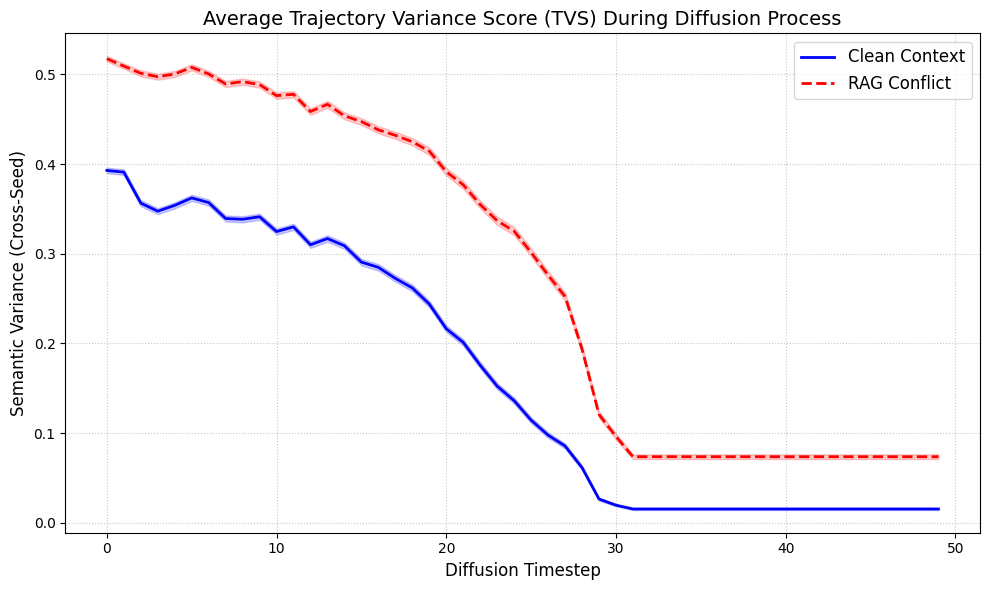

Graph saved to Google Drive as '/content/drive/MyDrive/tvs_conflict_graph.png'


In [13]:
# =====================================================================
# CELL 10: TVS VISUALIZATION (FIGURE GENERATION)
# =====================================================================
import matplotlib.pyplot as plt

# Calculate the mean variance across all samples at each timestep
mean_clean_tvs = np.mean(clean_raw, axis=0)
mean_conflict_tvs = np.mean(conflict_raw, axis=0)

# Optional: Calculate standard deviation for confidence intervals
std_clean_tvs = np.std(clean_raw, axis=0) / np.sqrt(NUM_FACTS)
std_conflict_tvs = np.std(conflict_raw, axis=0) / np.sqrt(NUM_FACTS)

timesteps = np.arange(clean_raw.shape[1])

plt.figure(figsize=(10, 6))
plt.plot(timesteps, mean_clean_tvs, label='Clean Context', color='blue', linewidth=2)
plt.fill_between(timesteps, mean_clean_tvs - std_clean_tvs, mean_clean_tvs + std_clean_tvs, color='blue', alpha=0.2)

plt.plot(timesteps, mean_conflict_tvs, label='RAG Conflict', color='red', linewidth=2, linestyle='--')
plt.fill_between(timesteps, mean_conflict_tvs - std_conflict_tvs, mean_conflict_tvs + std_conflict_tvs, color='red', alpha=0.2)

plt.title('Average Trajectory Variance Score (TVS) During Diffusion Process', fontsize=14)
plt.xlabel('Diffusion Timestep', fontsize=12)
plt.ylabel('Semantic Variance (Cross-Seed)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Save the figure directly for the manuscript to Google Drive
plt.savefig('/content/drive/MyDrive/tvs_conflict_graph.png', dpi=300)
plt.show()
print("Graph saved to Google Drive as '/content/drive/MyDrive/tvs_conflict_graph.png'")

In [14]:
# =====================================================================
# CELL 11: PER-DATASET ACCURACY BREAKDOWN
# =====================================================================
import torch
import json
from collections import defaultdict

# ---> LOAD THE VERIFIED DATASET FROM DISK <---
print("Loading Verified Master Dataset from Google Drive...")
with open("/content/drive/MyDrive/llada/verified_master_dataset.json", "r") as f:
    verified_eval_facts = json.load(f)

print("Calculating Per-Dataset Accuracy Signatures...")

# Dictionary to store correct and total counts for each dataset
# Structure: { "dataset_name": {"correct": 0, "total": 0} }
dataset_metrics = defaultdict(lambda: {"correct": 0, "total": 0})

model.eval()
with torch.no_grad():
    # Pass the full X tensor through the model
    # (Move to the same device as the model's weights)
    device = next(model.parameters()).device
    all_preds = model(X.to(device)).cpu().squeeze()

    for i in range(len(y)):
        true_label = int(y[i].item())
        pred_prob = all_preds[i].item()
        predicted_label = 1 if pred_prob >= 0.5 else 0

        # Map the tensor index back to the original fact index in the JSON
        # (Since we appended 2 samples per fact: index 0 and 1 belong to fact 0, etc.)
        original_fact_index = i // 2
        fact = verified_eval_facts[original_fact_index]

        # Safely get the dataset name (default to 'unknown' if missing)
        dataset_name = fact.get("dataset", "unknown").upper()

        # Update metrics
        dataset_metrics[dataset_name]["total"] += 1
        if true_label == predicted_label:
            dataset_metrics[dataset_name]["correct"] += 1

# =====================================================================
# PRINT THE STRATIFIED RESULTS
# =====================================================================
print("\n" + "="*55)
print("--- GLOBAL ACCURACY BREAKDOWN BY DATASET ---")
print("="*55)

# Sort alphabetically by dataset name for clean printing
for ds in sorted(dataset_metrics.keys()):
    metrics = dataset_metrics[ds]
    correct = metrics["correct"]
    total = metrics["total"]

    # Avoid division by zero just in case
    if total > 0:
        accuracy = (correct / total) * 100
        print(f"{ds:<15} | Accuracy: {accuracy:>5.2f}%  ({correct:>3}/{total:>3} samples)")
    else:
        print(f"{ds:<15} | No data found.")

print("="*55)

Loading Verified Master Dataset from Google Drive...
Calculating Per-Dataset Accuracy Signatures...

--- GLOBAL ACCURACY BREAKDOWN BY DATASET ---
COUNTERFACT     | Accuracy: 63.62%  (1107/1740 samples)
POPQA           | Accuracy: 71.51%  (379/530 samples)
SCIQ            | Accuracy: 75.41%  (2184/2896 samples)
SYNTHETIC       | Accuracy: 79.67%  (580/728 samples)


In [15]:
# =====================================================================
# CELL 10: ERROR ANALYSIS - EXTRACTING FALSE NEGATIVES
# =====================================================================
import pandas as pd
import torch

print("Extracting False Negatives (Missed Hallucinations)...")

# Assuming X, y, and raw_eval_pool/verified_eval_facts are still in memory
# We run the full dataset through the trained model sequentially to keep indices aligned
model.eval()
false_negatives = []

with torch.no_grad():
    # Pass the full X tensor (all verified facts) through the model
    all_preds = model(X.to(model.lstm.weight_ih_l0.device))

    for i in range(len(y)):
        true_label = y[i].item()
        pred_prob = all_preds[i].item()
        predicted_label = 1 if pred_prob >= 0.5 else 0

        # We only care about Conflict samples (Label 1) that were predicted as Clean (0)
        if true_label == 1 and predicted_label == 0:
            # Map back to the original fact (accounting for the 2x expansion of X: clean=0, conflict=1)
            original_fact_index = i // 2

            fact = verified_eval_facts[original_fact_index]

            false_negatives.append({
                "Subject": fact["subject"],
                "Dataset": fact["dataset"],
                "True Answer": fact["true"],
                "RAG Fake (Conflict)": fact["fake"],
                "Model Confidence (Prob)": round(pred_prob, 4)
            })

# Save to CSV directly in Google Drive
df_errors = pd.DataFrame(false_negatives)
df_errors.to_csv("/content/drive/MyDrive/llada/tvs_false_negatives.csv", index=False)

print("\n" + "="*50)
print(f"Found {len(df_errors)} missed hallucinations.")
print("Saved to Google Drive as '/content/drive/MyDrive/llada/tvs_false_negatives.csv'")
print("="*50)
display(df_errors.head(10))

Extracting False Negatives (Missed Hallucinations)...

Found 945 missed hallucinations.
Saved to Google Drive as '/content/drive/MyDrive/llada/tvs_false_negatives.csv'


,Subject,Dataset,True Answer,RAG Fake (Conflict),Model Confidence (Prob)
0,Iron,synthetic,Fe,Ar,0.4649
1,Valdemar III of Denmark,popqa,Denmark,Frascati,0.4792
2,Herzeleid,counterfact,German,Greek,0.4032
3,The,sciq,sun,Moon,0.1549
4,De finibus bonorum et malorum,counterfact,Latin,Italian,0.2765
5,An,sciq,ecosystem,community,0.3936
6,Hajime Mizoguchi,counterfact,Tokyo,London,0.4746
7,Adam Sandler,counterfact,English,French,0.4563
8,Acid,sciq,acid rain,carbon rain,0.2332
9,Eukaryotic,sciq,organelle,mitochondria,0.2187
